## Librerias a utilizar

In [35]:
import numpy as np
from itertools import combinations
import random
import pandas as pd
import matplotlib.pyplot as plt

## Construccion de funciones principales

In [36]:
def coincidencias(lista_cumple):
    parejas = combinations(lista_cumple, 2)
    return any(dia_1 == dia_2 for dia_1, dia_2 in parejas)

# n, tamaño grupo
# N numero de repeticiones del experimento
def sim_cumple(n, N):
    contador = 0
    for _ in range(N):
        lista_sim = random.choices(range(1, 366), k=n)
        if coincidencias(lista_sim):
            contador += 1

    return contador/N

def proba_comb(n):
    producto = 1
    for i in range(1, n):
        producto *= (1-(i/365))
    return 1-producto # aqui se usa el complemento ya que el resultado del ciclo for es la probabilidad de que nadie coincida en cumpleaños

### Punto 1

In [37]:
n = 60
N = 1000
num_personas = [x for x in range(1, n)]
probabilidad_combinatoria = np.array([proba_comb(x) for x in range(1,n)])
probablidad_monte_carlo = np.array([sim_cumple(x, N) for x in range(1, n)])
diferencia = np.abs(probabilidad_combinatoria-probablidad_monte_carlo)

resultados = pd.DataFrame({'Numero personas':num_personas,
                           'Probabilidad combinatoria': probabilidad_combinatoria,
                           'Probabilidad Monte Carlo': probablidad_monte_carlo,
                           'Diferencia': diferencia})

resultados

,Numero personas,Probabilidad combinatoria,Probabilidad Monte Carlo,Diferencia
0,1,0.000000,0.000,0.000000
1,2,0.002740,0.005,0.002260
2,3,0.008204,0.006,0.002204
3,4,0.016356,0.017,0.000644
4,5,0.027136,0.026,0.001136
5,6,0.040462,0.040,0.000462
6,7,0.056236,0.063,0.006764
7,8,0.074335,0.066,0.008335
8,9,0.094624,0.102,0.007376
9,10,0.116948,0.097,0.019948


### Punto 2

In [38]:
mayor_error = resultados.nlargest(n=5, columns='Diferencia')
mayor_error

,Numero personas,Probabilidad combinatoria,Probabilidad Monte Carlo,Diferencia
18,19,0.379119,0.421,0.041881
12,13,0.194410,0.160,0.034410
24,25,0.568700,0.594,0.025300
25,26,0.598241,0.619,0.020759
34,35,0.814383,0.794,0.020383


### Punto 3

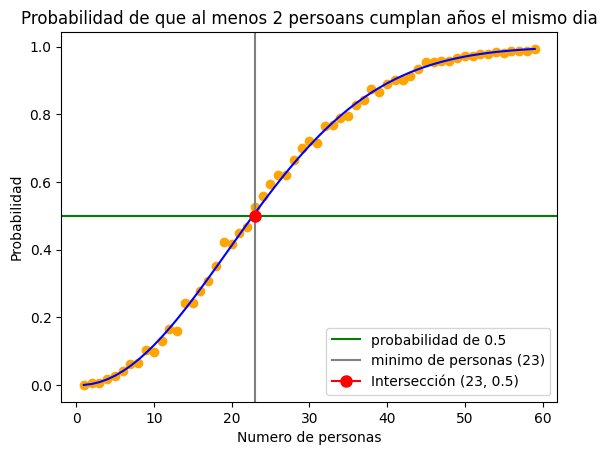

In [39]:
plt.plot(resultados['Numero personas'], resultados['Probabilidad combinatoria'], color='blue')
plt.scatter(resultados['Numero personas'], resultados['Probabilidad Monte Carlo'], color='orange')
plt.xlabel('Numero de personas')
plt.ylabel('Probabilidad')
plt.title('Probabilidad de que al menos 2 persoans cumplan años el mismo dia')
plt.axhline(y=0.5, color='green', label='probabilidad de 0.5')
plt.axvline(x=23, color='gray', label='minimo de personas (23)')
plt.plot(23, 0.5, marker='o', color='red', markersize=8, label='Intersección (23, 0.5)')
plt.legend()

### Punto 4

Text(0, 0.5, 'Error absoluto')

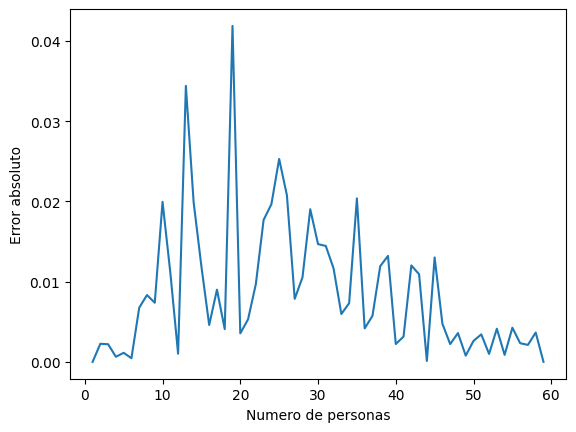

In [40]:
plt.plot(resultados['Numero personas'], resultados['Diferencia'])
plt.xlabel('Numero de personas')
plt.ylabel('Error absoluto')

La región donde mejor parece aproximarse la simulación es donde el número de personas es mayor, pero al inicio donde el número de personas es bajo, parece que la simulación tiene más error.

### Punto 5

In [41]:
resultados = resultados.sort_values(by='Probabilidad combinatoria')
mayor_05 = resultados[resultados['Probabilidad combinatoria']>0.5]
mayor_05 = mayor_05.reset_index(drop=True)
valor_min = int(mayor_05.loc[0, 'Numero personas'])
valor_min
valor_exacto = float(mayor_05.loc[0, 'Probabilidad combinatoria'])
valor_exacto

0.5072972343239854

### Punto 6

In [42]:
num_sim = np.array([100, 1000, 10000, 100000])
lista_sim = np.array([sim_cumple(valor_min, x) for x in num_sim])
prob_exac = np.array([valor_exacto]*4)
simulaciones_05 = pd.DataFrame({'Repeticiones': num_sim.astype(str),
                                'Probabilidad simulado': lista_sim,
                                'Probabilidad exacta': prob_exac,
                                'Error': np.abs(lista_sim-prob_exac)})
simulaciones_05

,Repeticiones,Probabilidad simulado,Probabilidad exacta,Error
0,100,0.53000,0.507297,0.022703
1,1000,0.50700,0.507297,0.000297
2,10000,0.51120,0.507297,0.003903
3,100000,0.50888,0.507297,0.001583


### Punto 7

Text(0.5, 1.0, 'Numero de simulaciones y su error al compararlo con la probabilidad exacta')

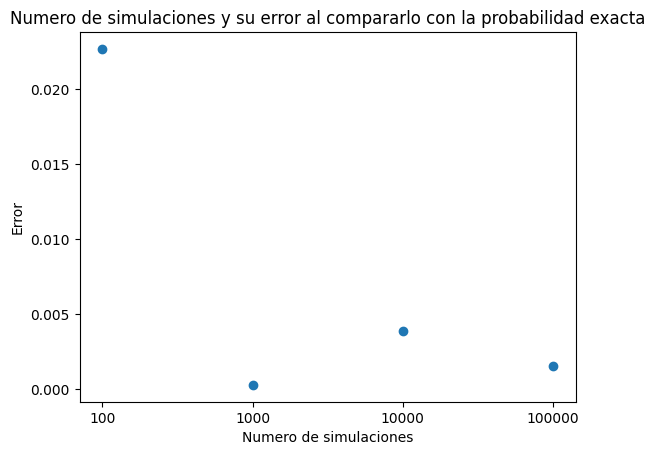

In [43]:
plt.scatter(simulaciones_05['Repeticiones'] ,simulaciones_05['Error'])
plt.xlabel('Numero de simulaciones')
plt.ylabel('Error')
plt.title('Numero de simulaciones y su error al compararlo con la probabilidad exacta')

Mientras que el numero de simulaciones aumenta el error va dismunuyendo, es decir, mientras más simulaciones hagamos más nos acercamos al valor real.

### Punto 8

In [44]:
def min_personas(resultados, probabilidad):
    mayores = resultados[resultados['Probabilidad combinatoria']>probabilidad]
    mayores = mayores.reset_index(drop=True)
    valor_min = int(mayores.loc[0, 'Numero personas'])
    return valor_min

niveles_proba = np.array([0.25, 0.5, 0.75, 0.9, 0.99])

cant_personas = np.array([min_personas(resultados, x) for x in niveles_proba])

cant_personas_superior = pd.DataFrame({'Nivel de probabilidad': niveles_proba,
                                       'Numero de personas': cant_personas})

cant_personas_superior

,Nivel de probabilidad,Numero de personas
0,0.25,15
1,0.50,23
2,0.75,32
3,0.90,41
4,0.99,57


Text(0.5, 1.0, 'Numero de personas que se necesitan para obtener ciertas probabilidades')

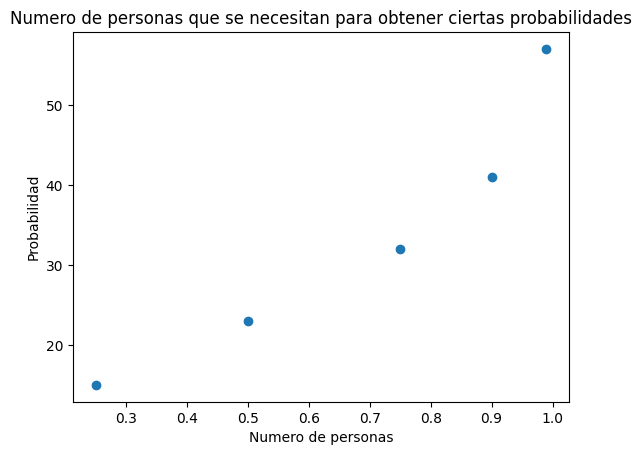

In [45]:
plt.scatter(cant_personas_superior['Nivel de probabilidad'], cant_personas_superior['Numero de personas'])
plt.xlabel('Numero de personas')
plt.ylabel('Probabilidad')
plt.title('Numero de personas que se necesitan para obtener ciertas probabilidades')